# Notebook 4: Huba-Specific ReLIGn + GoRep End-to-End Pipeline


There are two modes:

- **Safe default mode** (`RUN_RELIGN_BIG = False`): prepares Huba-specific ReLIGn-compatible `.g/.subs` artifacts from the Huba GoCCvA evidence so the notebook always executes.
- **Full ReLIGn mode** (`RUN_RELIGN_BIG = True`): attempts to run ReLIGn's Java BIG generation (`ComputePrecision.jar`, `IGInitializer.jar`, `InstanceGraphRules.jar`) on the Huba log and PNML. This requires the external ReLIGn runtime, especially Java and MySQL configured as ReLIGn expects.

The repair part runs in both modes.


## 0. Bootstrap


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'Semantics').exists():
    REPO_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / 'Semantics').exists():
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = Path(r'C:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Repository root:', REPO_ROOT)


Repository root: c:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026


## 1. Imports and Mode


In [2]:
import pandas as pd
import shutil
from IPython.display import Image, display

from GoRep.gorep_huba import (
    PROCESS_MODEL_PATH,
    goal_alignment_table,
    load_huba_inputs,
    run_huba_analysis,
    summary_with_frequency,
)
from GoRep.gorep_realign import (
    HUBA_RELIGN_DIR,
    build_huba_relign_graph_from_detailed,
    prepare_huba_relign_workspace,
    read_relign_frequent_fragments,
    read_relign_lig_graph,
    relign_environment_status,
    relign_graph_label_table,
    relign_mysql_setup_options,
    relign_fragment_summary,
    render_relign_graph,
    run_huba_relign_big,
    write_graph_as_relign_g,
    write_huba_fragments_as_subs,
)
from GoRep.gorep_repair import (
    anomaly_target_evidence,
    derive_alignment_patterns,
    generate_repair_candidates,
    gorep_function_map,
    pattern_glossary,
    score_candidates,
    target_status_evidence,
)
from GoRep.gorep_repair_ops import (
    apply_candidate_repair,
    check_repair_soundness,
    compare_summary,
    export_repair_variant,
    render_petri_net_png,
    render_petri_net_process_style_png,
    soundness_function_map,
    pnml_file_pm4py_visualization,
    render_pnml_file_png,
    rerun_goccva_for_variant,
)
from GoRep.gorep_viz import (
    render_alignment_move_graph,
    render_candidate_score_breakdown,
    render_theta_heatmap,
)
from Ui.goccva_ui import render_case_distribution_matrix, render_from_analysis

# Set this to True only when Java/MySQL are configured for ReLIGn BIG generation.
RUN_RELIGN_BIG = False
print('RUN_RELIGN_BIG =', RUN_RELIGN_BIG)


RUN_RELIGN_BIG = False


## 1.5 Function Map

These are the main GoRep functions used in this notebook and where they live.


In [3]:
gorep_function_map()


,step,function,file,output
0,GoCCvA baseline,run_huba_analysis,GoRep/gorep_huba.py,"summary, detailed, contribution_to_targets"
1,Target status evidence,target_status_evidence,GoRep/gorep_repair.py,Theta/status row per target per alignment step
2,Anomaly patterns,derive_alignment_patterns,GoRep/gorep_repair.py,skipped/inserted/repeated/swapped patterns
3,Goal impact,anomaly_target_evidence,GoRep/gorep_repair.py,which anomaly affects which target
4,Repair candidates,generate_repair_candidates,GoRep/gorep_repair.py,candidate add/delete/swap/loop repair templates
5,Candidate ranking,score_candidates,GoRep/gorep_repair.py,multicriteria candidate ranking


## 1.6 Pattern Glossary

This table explains each high-level anomaly pattern and how it comes from log/model moves.


In [4]:
pattern_glossary()


,pattern,low-level signal,meaning,repair intuition
0,skipped,model move,"The process model expected an activity, but th...",Decide whether to forbid the bypass or add a c...
1,inserted,log move,The log executed an extra activity that the pr...,Add the behavior only if it is a positive/acce...
2,repeated,extra occurrence compared with model-side alig...,An activity appears more often than expected.,Add a guarded loop if repetition is legitimate...
3,swapped,observed local order contradicts model-side order,Two activities occur in the opposite order.,"Consider reordering, a swap template, or a par..."


## 2. Load Huba Inputs and Run Baseline GoCCvA


In [29]:
inputs = load_huba_inputs()
analysis_log, variants, summary, detailed, contribution_to_targets = run_huba_analysis(
    inputs,
    variant_limit=10,
)
summary_with_frequency(summary, variants)


parsing log, completed traces ::   0%|          | 0/10357 [00:00<?, ?it/s]

C:\Users\jcavi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pm4py\objects\conversion\log\variants\to_data_frame.py:73: UserWarning: no explicit representation of timezones available for np.datetime64
  ev[attr] = np.datetime64(ev[attr])
C:\Users\jcavi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pm4py\objects\log\util\dataframe_utils.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
C:\Users\jcavi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pm4py\objects\log\util\dataframe_utils.py:177: UserWarning: Could not infer format, so each element will be parsed individually, 

aligning log, completed variants ::   0%|          | 0/10 [00:00<?, ?it/s]

,trace_id,trace,alignment_cost,fitness,traditional_class,goal_class,frequency
0,2,Declaration SUBMITTED by EMPLOYEE | Declaratio...,0,1.000000,optimal,Strongly compliant,2411
1,7,Declaration SUBMITTED by EMPLOYEE | Declaratio...,0,1.000000,optimal,Non-compliant,174
2,1,Declaration SUBMITTED by EMPLOYEE | Declaratio...,10000,0.875000,non-optimal,Strongly compliant,4566
3,3,Declaration SUBMITTED by EMPLOYEE | Declaratio...,20000,0.714286,non-optimal,Strongly compliant,1392
4,4,Declaration SUBMITTED by EMPLOYEE | Declaratio...,30000,0.625000,non-optimal,Strongly compliant,575
5,5,Declaration SUBMITTED by EMPLOYEE | Declaratio...,30000,0.727273,non-optimal,Weakly compliant,342
6,6,Declaration SUBMITTED by EMPLOYEE | Declaratio...,20000,0.833333,non-optimal,Weakly compliant,183
7,9,Declaration SUBMITTED by EMPLOYEE | Declaratio...,40000,0.666667,non-optimal,Weakly compliant,77
8,10,Declaration SUBMITTED by EMPLOYEE | Declaratio...,60000,0.454545,non-optimal,Weakly compliant,57
9,8,Declaration SAVED by EMPLOYEE,30000,0.250000,non-optimal,Non-compliant,134


In [6]:
render_case_distribution_matrix(
    summary=summary,
    title='Huba baseline before repair',
    targets=inputs.targets,
)


{'summary': [{'trace_id': 2,
   'trace': 'Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration APPROVED by BUDGET OWNER | Declaration FINAL_APPROVED by SUPERVISOR | Request Payment | Payment Handled',
   'alignment_cost': 0,
   'fitness': 1.0,
   'traditional_class': 'optimal',
   'goal_class': 'Strongly compliant'},
  {'trace_id': 1,
   'trace': 'Declaration SUBMITTED by EMPLOYEE | Declaration APPROVED by ADMINISTRATION | Declaration FINAL_APPROVED by SUPERVISOR | Request Payment | Payment Handled',
   'alignment_cost': 10000,
   'fitness': 0.875,
   'traditional_class': 'non-optimal',
   'goal_class': 'Strongly compliant'},
  {'trace_id': 3,
   'trace': 'Declaration SUBMITTED by EMPLOYEE | Declaration FINAL_APPROVED by SUPERVISOR | Request Payment | Payment Handled',
   'alignment_cost': 20000,
   'fitness': 0.7142857142857143,
   'traditional_class': 'non-optimal',
   'goal_class': 'Strongly compliant'},
  {'trace_id': 4,
   'trace': 'Declaration 

## 3. Render Baseline Goal-Oriented Alignments


In [7]:
render_from_analysis(
    activity_abbreviations=inputs.activity_abbreviations,
    summary=summary,
    detailed=detailed,
    contribution_to_targets=contribution_to_targets,
    title='Huba baseline GoCCvA alignments',
)


# Huba baseline GoCCvA alignments

The following cases illustrate combinations of alignment class and target-fulfilment class. Each table separates the process alignment row from the target-specific interpretation rows.

## 4. Prepare the Huba-Specific ReLIGn Workspace


In [8]:
relign_status = relign_environment_status()
relign_status


,check,ok,detail
0,ReLIGn zip available,True,C:\Users\jcavi\Downloads\ReLIGn-tool-main.zip
1,Java available,True,C:\Program Files\Common Files\Oracle\Java\java...
2,MySQL client available,False,
3,MySQL server command available,False,
4,Graphviz dot available,False,
5,Docker available,True,C:\Program Files\Docker\Docker\resources\bin\d...
6,Java version,True,"java version ""23"" 2024-09-17"
7,Docker daemon running,False,


### MySQL / Java Setup Needed for `RUN_RELIGN_BIG=True`

The full ReLIGn BIG generation is not only Python. It expects Java 8 and a local MySQL/MariaDB database setup. The table below gives the concrete setup options. On this machine, notebook safe mode remains the executable path until MySQL server/client and Java 8 are configured.


In [9]:
relign_mysql_setup_options()


,option,what to do,command sketch,notes
0,Native MySQL 8.0.x,"Install MySQL Server and client, ensure mysql ...",winget install Oracle.MySQL,ReLIGn README says MySQL 8.0.x up to 8.0.34 su...
1,MariaDB local server,"Install MariaDB, set lower_case_table_names=1 ...",winget install MariaDB.Server,Matches the ReLIGn README's MariaDB note.
2,Docker MySQL 8.0.34,"Start Docker Desktop, then run a MySQL contain...",docker run --name relign-mysql -e MYSQL_ALLOW_...,Requires Docker daemon running. The container ...
3,Java 8,Install Java 8 and put it before Java 23 on PA...,winget install EclipseAdoptium.Temurin.8.JRE,The current machine reports Java 23; ReLIGn as...
4,Graphviz,Install Graphviz if you want PM4Py/Graphviz na...,winget install Graphviz.Graphviz,"Notebook has a Matplotlib fallback, but dot gi..."


In [10]:
huba_relign_workspace = prepare_huba_relign_workspace(
    inputs,
    process_model_path=REPO_ROOT / PROCESS_MODEL_PATH,
)
huba_relign_workspace


exporting log, completed traces ::   0%|          | 0/10357 [00:00<?, ?it/s]

{'workspace': WindowsPath('C:/Users/jcavi/Desktop/Juanita_Kogi/work-GoCCvA-2026/GoRep/relign_huba'),
 'dataset_name': WindowsPath('HubaDomesticDeclarations'),
 'log_path': WindowsPath('C:/Users/jcavi/Desktop/Juanita_Kogi/work-GoCCvA-2026/GoRep/relign_huba/HubaDomesticDeclarations.xes'),
 'pnml_path': WindowsPath('C:/Users/jcavi/Desktop/Juanita_Kogi/work-GoCCvA-2026/GoRep/relign_huba/HubaDomesticDeclarations_petriNet.pnml'),
 'big_dir': WindowsPath('C:/Users/jcavi/Desktop/Juanita_Kogi/work-GoCCvA-2026/GoRep/relign_huba/big'),
 'out_g_file': WindowsPath('C:/Users/jcavi/Desktop/Juanita_Kogi/work-GoCCvA-2026/GoRep/relign_huba/HubaDomesticDeclarations.g')}

## 5. Generate or Build Huba-Specific ReLIGn Artifacts

If `RUN_RELIGN_BIG` is `True`, this cell attempts the real ReLIGn Java generation for Huba. If it fails, the notebook prints the command output. In safe mode, it creates Huba-specific ReLIGn-compatible artifacts from the Huba evidence. These artifacts use ReLIGn's `.g/.subs` format and are specific to Huba, but they are not produced by the external BIG runtime.


In [11]:
theta_rows = target_status_evidence(detailed)
patterns = derive_alignment_patterns(detailed, summary, variants)
evidence = anomaly_target_evidence(patterns, theta_rows)

if RUN_RELIGN_BIG:
    big_result = run_huba_relign_big(huba_relign_workspace, timeout=900)
    print('BIG ok:', big_result['ok'])
    for log in big_result['logs']:
        print('\nCOMMAND:', log['command'])
        print('RETURN:', log['returncode'])
        print('STDOUT:', log['stdout'][-1000:])
        print('STDERR:', log['stderr'][-1000:])
    huba_g_path = big_result['out_g_file']
else:
    huba_graph = build_huba_relign_graph_from_detailed(detailed)
    huba_g_path = write_graph_as_relign_g(huba_graph, HUBA_RELIGN_DIR / 'HubaDomesticDeclarations.g')
    huba_subs_path = write_huba_fragments_as_subs(patterns, HUBA_RELIGN_DIR / 'HubaDomesticDeclarations.subs')
    print('Wrote Huba-specific ReLIGn-compatible .g:', huba_g_path)
    print('Wrote Huba-specific ReLIGn-compatible .subs:', huba_subs_path)


Wrote Huba-specific ReLIGn-compatible .g: C:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026\GoRep\relign_huba\HubaDomesticDeclarations.g
Wrote Huba-specific ReLIGn-compatible .subs: C:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026\GoRep\relign_huba\HubaDomesticDeclarations.subs


## 6. Render the Huba-Specific LIG / Instance Graph


<Axes: title={'center': 'Huba-specific ReLIGn/LIG artifact'}>

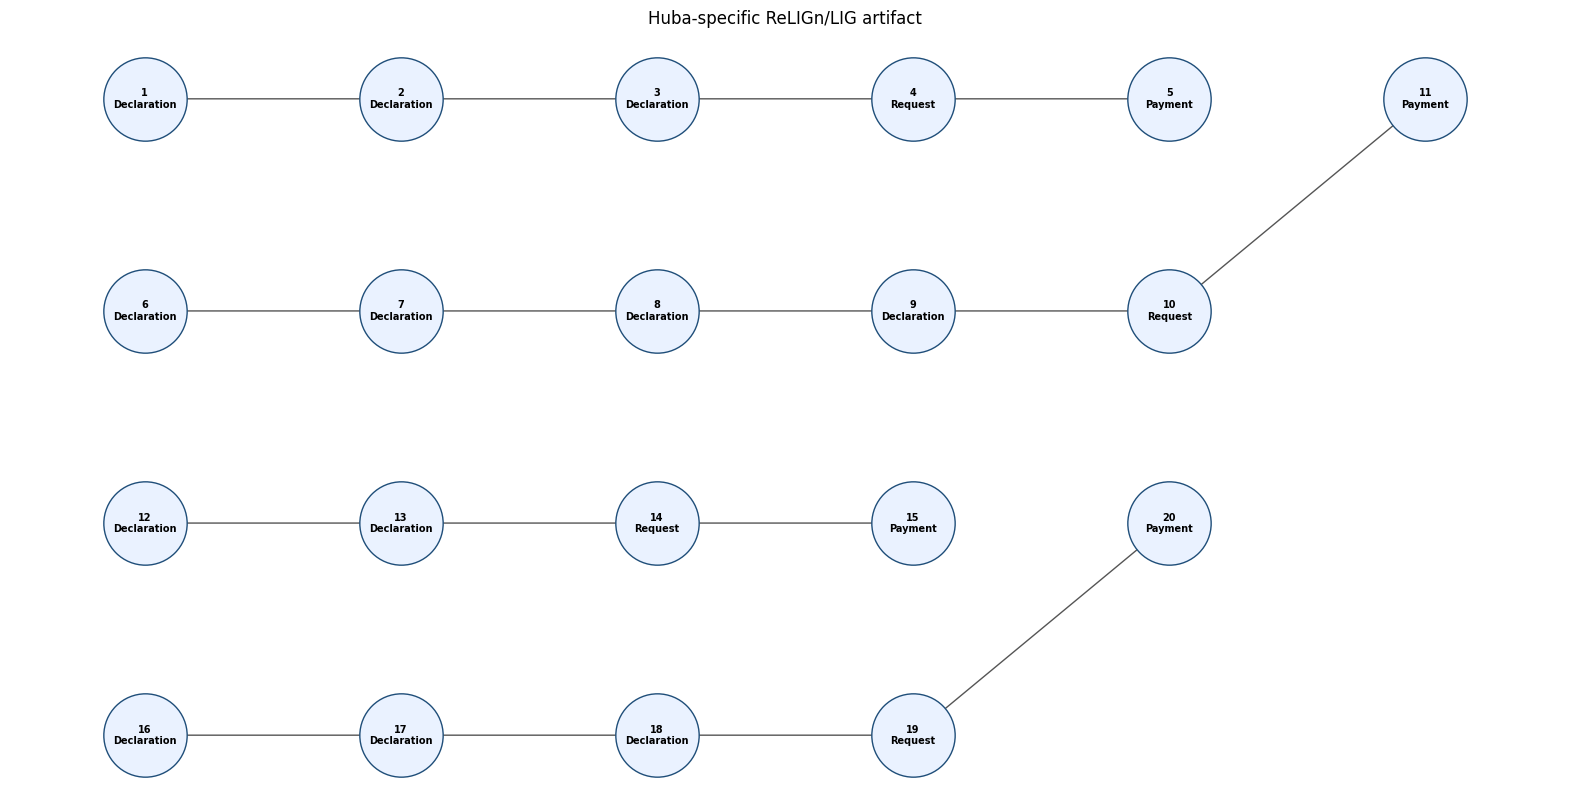

In [12]:
huba_lig = read_relign_lig_graph(huba_g_path, max_nodes=45)
render_relign_graph(huba_lig, title='Huba-specific ReLIGn/LIG artifact', label_width=14, node_size=3600, figsize=(20, 10))


### LIG Node Label Table

The graph labels can still be dense, so this table lists the full node labels.


In [13]:
relign_graph_label_table(huba_lig)


,node,label
0,1,Declaration
1,2,Declaration
2,3,Declaration
3,4,Request
4,5,Payment
5,6,Declaration
6,7,Declaration
7,8,Declaration
8,9,Declaration
9,10,Request


## 7. Huba-Specific Frequent/Anomalous Fragments


In [14]:
# In safe mode this points to the Huba-specific .subs generated from anomaly evidence.
# In full ReLIGn mode, replace this with the Huba .subs produced by the frequent-subgraph mining step.
huba_subs_path = HUBA_RELIGN_DIR / 'HubaDomesticDeclarations.subs'
fragments = read_relign_frequent_fragments(huba_subs_path, limit=8)
relign_fragment_summary(fragments)


,fragment_id,nodes,edges,activities
0,1,2,1,skipped | Declaration_APPROVED_by_BUDGET_OWNER
1,2,2,1,skipped | Declaration_APPROVED_by_ADMINISTRATION
2,3,2,1,repeated | Declaration_APPROVED_by_PRE_APPROVER
3,4,2,1,inserted | Declaration_APPROVED_by_PRE_APPROVER


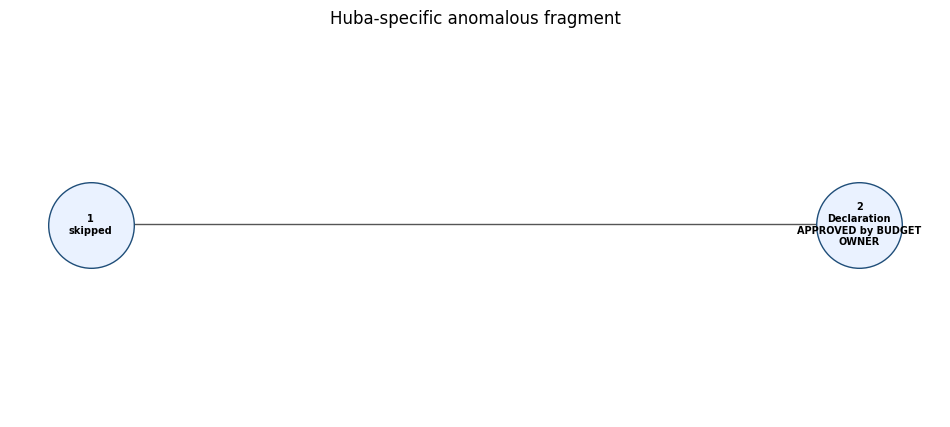

In [15]:
if fragments:
    render_relign_graph(fragments[0], title='Huba-specific anomalous fragment', label_width=18, node_size=3800, figsize=(12, 5))


## 8. Explain One Huba Variant: Moves and Target Evolution


<Axes: title={'center': 'Real alignment moves for trace variant 1'}>

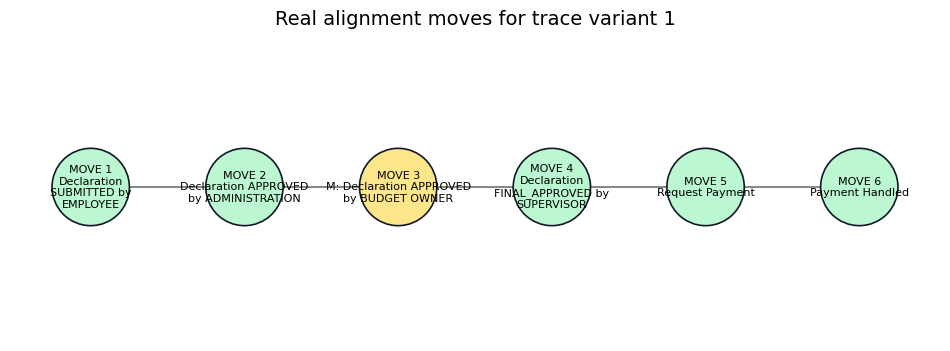

In [16]:
trace_id_to_explain = 1
render_alignment_move_graph(detailed, trace_id=trace_id_to_explain)


<Axes: title={'center': 'Theta target-status evolution for trace variant 1'}, xlabel='Alignment step'>

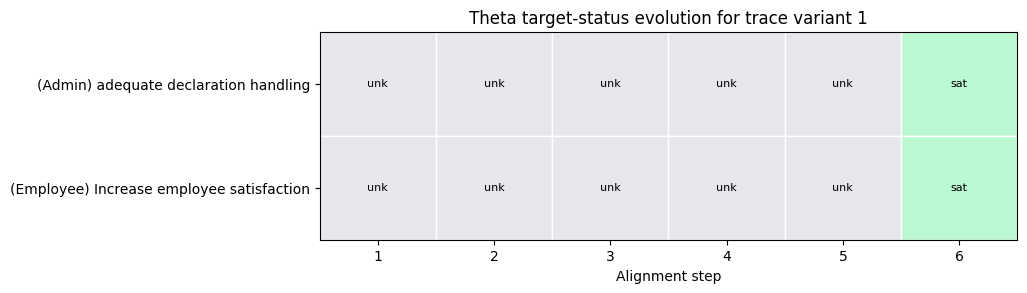

In [17]:
render_theta_heatmap(theta_rows, trace_id=trace_id_to_explain)


## 9. Structured Evidence: gamma*, Patterns, Goal Impact


In [18]:
gamma_table = goal_alignment_table(detailed, summary, variants)
gamma_table[['trace_id', 'frequency', 'traditional_class', 'goal_class', 'alignment_cost', 'Theta_i final', 'trace']]


,trace_id,frequency,traditional_class,goal_class,alignment_cost,Theta_i final,trace
0,1,4566,non-optimal,Strongly compliant,10000,(Admin) adequate declaration handling: satisfi...,Declaration SUBMITTED by EMPLOYEE | Declaratio...
1,2,2411,optimal,Strongly compliant,0,(Admin) adequate declaration handling: satisfi...,Declaration SUBMITTED by EMPLOYEE | Declaratio...
2,3,1392,non-optimal,Strongly compliant,20000,(Admin) adequate declaration handling: satisfi...,Declaration SUBMITTED by EMPLOYEE | Declaratio...
3,4,575,non-optimal,Strongly compliant,30000,(Admin) adequate declaration handling: satisfi...,Declaration SUBMITTED by EMPLOYEE | Declaratio...


In [19]:
patterns.sort_values(['pattern', 'frequency'], ascending=[True, False])


,trace_id,frequency,pattern,activity,traditional_class,goal_class,source
3,4,575,inserted,Declaration APPROVED by PRE_APPROVER,non-optimal,Strongly compliant,pm4py alignment
6,4,575,repeated,Declaration APPROVED by PRE_APPROVER,non-optimal,Strongly compliant,trace frequency vs alignment
0,1,4566,skipped,Declaration APPROVED by BUDGET OWNER,non-optimal,Strongly compliant,pm4py alignment
1,3,1392,skipped,Declaration APPROVED by ADMINISTRATION,non-optimal,Strongly compliant,pm4py alignment
2,3,1392,skipped,Declaration APPROVED by BUDGET OWNER,non-optimal,Strongly compliant,pm4py alignment
4,4,575,skipped,Declaration APPROVED by ADMINISTRATION,non-optimal,Strongly compliant,pm4py alignment
5,4,575,skipped,Declaration APPROVED by BUDGET OWNER,non-optimal,Strongly compliant,pm4py alignment


In [20]:
evidence.sort_values(['repair_pressure', 'frequency'], ascending=[False, False])


,trace_id,frequency,pattern,activity,target,target_status,goal_class,repair_pressure
0,1,4566,skipped,Declaration APPROVED by BUDGET OWNER,(Employee) Increase employee satisfaction,satisfied,Strongly compliant,False
1,1,4566,skipped,Declaration APPROVED by BUDGET OWNER,(Admin) adequate declaration handling,satisfied,Strongly compliant,False
2,3,1392,skipped,Declaration APPROVED by ADMINISTRATION,(Admin) adequate declaration handling,satisfied,Strongly compliant,False
3,3,1392,skipped,Declaration APPROVED by ADMINISTRATION,(Employee) Increase employee satisfaction,satisfied,Strongly compliant,False
4,3,1392,skipped,Declaration APPROVED by BUDGET OWNER,(Admin) adequate declaration handling,satisfied,Strongly compliant,False
5,3,1392,skipped,Declaration APPROVED by BUDGET OWNER,(Employee) Increase employee satisfaction,satisfied,Strongly compliant,False
6,4,575,inserted,Declaration APPROVED by PRE_APPROVER,(Admin) adequate declaration handling,satisfied,Strongly compliant,False
7,4,575,inserted,Declaration APPROVED by PRE_APPROVER,(Employee) Increase employee satisfaction,satisfied,Strongly compliant,False
8,4,575,skipped,Declaration APPROVED by ADMINISTRATION,(Admin) adequate declaration handling,satisfied,Strongly compliant,False
9,4,575,skipped,Declaration APPROVED by ADMINISTRATION,(Employee) Increase employee satisfaction,satisfied,Strongly compliant,False


## 10. Generate and Rank Repair Candidates


In [21]:
candidates = generate_repair_candidates(evidence)
ranking = score_candidates(candidates)
ranking[['candidate_id', 'operation', 'trigger', 'support', 'affected_targets', 'description', 'overall_score']]


,candidate_id,operation,trigger,support,affected_targets,description,overall_score
2,R3,controlled loop,repeated:Declaration APPROVED by PRE_APPROVER,1150,"((Admin) adequate declaration handling, (Emplo...",Add a guarded loop for repeated 'Declaration A...,0.596
0,R1,add/delete decision,skipped:Declaration APPROVED by BUDGET OWNER,13066,"((Admin) adequate declaration handling, (Emplo...",Decide whether to add a controlled bypass for ...,0.584
3,R4,add,inserted:Declaration APPROVED by PRE_APPROVER,1150,"((Admin) adequate declaration handling, (Emplo...",Consider adding observed activity 'Declaration...,0.570
1,R2,add/delete decision,skipped:Declaration APPROVED by ADMINISTRATION,3934,"((Admin) adequate declaration handling, (Emplo...",Decide whether to add a controlled bypass for ...,0.514


<Axes: title={'center': 'Why candidates are ranked: multicriteria score components'}, xlabel='candidate_id', ylabel='Normalized criterion score'>

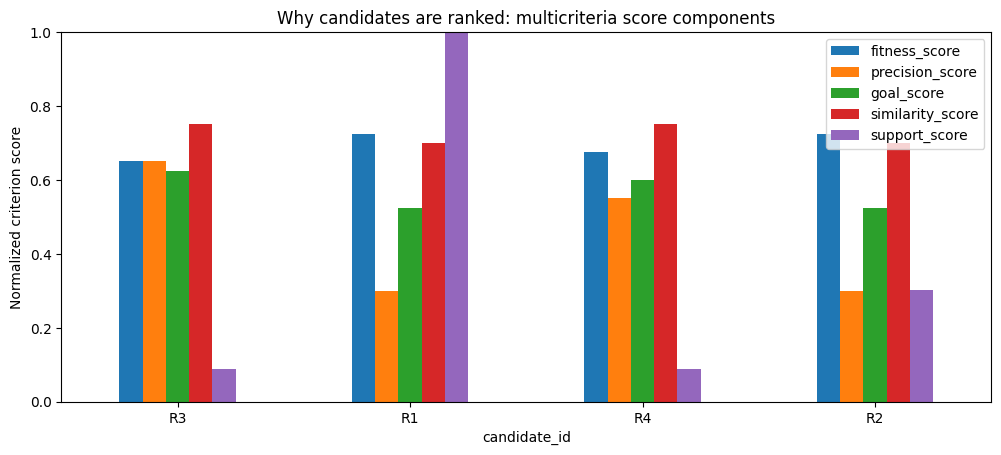

In [22]:
render_candidate_score_breakdown(ranking, top_n=min(5, len(ranking)))


## 11. Apply Concrete Petri-Net Repairs and Check Soundness


In [23]:
repair_rows = []
repair_variants = []
for _, candidate in ranking.head(8).iterrows():
    variant = apply_candidate_repair(inputs.petri_net, candidate)
    soundness = check_repair_soundness(variant)
    repair_variants.append((variant, soundness))
    repair_rows.append({**soundness, 'description': variant.description})

repair_soundness = pd.DataFrame(repair_rows)
repair_soundness


,candidate_id,operation,trigger,wfnet,easy_soundness,description
0,R3,controlled loop,repeated:Declaration APPROVED by PRE_APPROVER,False,True,Add a guarded loop for repeated 'Declaration A...
1,R1,add/delete decision,skipped:Declaration APPROVED by BUDGET OWNER,False,True,Decide whether to add a controlled bypass for ...
2,R4,add,inserted:Declaration APPROVED by PRE_APPROVER,False,True,Consider adding observed activity 'Declaration...
3,R2,add/delete decision,skipped:Declaration APPROVED by ADMINISTRATION,False,True,Decide whether to add a controlled bypass for ...


## 12. Select First Easy-Sound Repair and Export It


In [24]:
sound_variants = [variant for variant, soundness in repair_variants if soundness.get('easy_soundness')]
if not sound_variants:
    raise RuntimeError('No easy-sound repair variant found. Try more candidates or revise repair templates.')
selected_variant = sound_variants[0]
exported_path = export_repair_variant(selected_variant)
print('Selected repair:', selected_variant.name, selected_variant.operation, selected_variant.trigger)
print('Exported PNML:', exported_path)


Selected repair: R3 controlled loop repeated:Declaration APPROVED by PRE_APPROVER
Exported PNML: C:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026\GoRep\repaired_models\R3_controlled_loop.pnml


## 13.5 Visualize the Petri Net Before and After Repair

For presentation, this cell renders the original and repaired Petri nets in a process-diagram style close to the paper figure: places are circles, visible transitions are activity boxes, hidden/tau transitions are black bars, and arrows follow the PNML layout. The rendering uses the PNML coordinates extracted by the local parser, so it is easier to read than the generic fallback layout.


Original PNML: c:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026\content\TUEReimbursement\domestic_declaration_ilpn_updated.pnml
Repaired PNML: C:\Users\jcavi\Desktop\Juanita_Kogi\work-GoCCvA-2026\GoRep\repaired_models\R3_controlled_loop.pnml

Original Huba Petri net


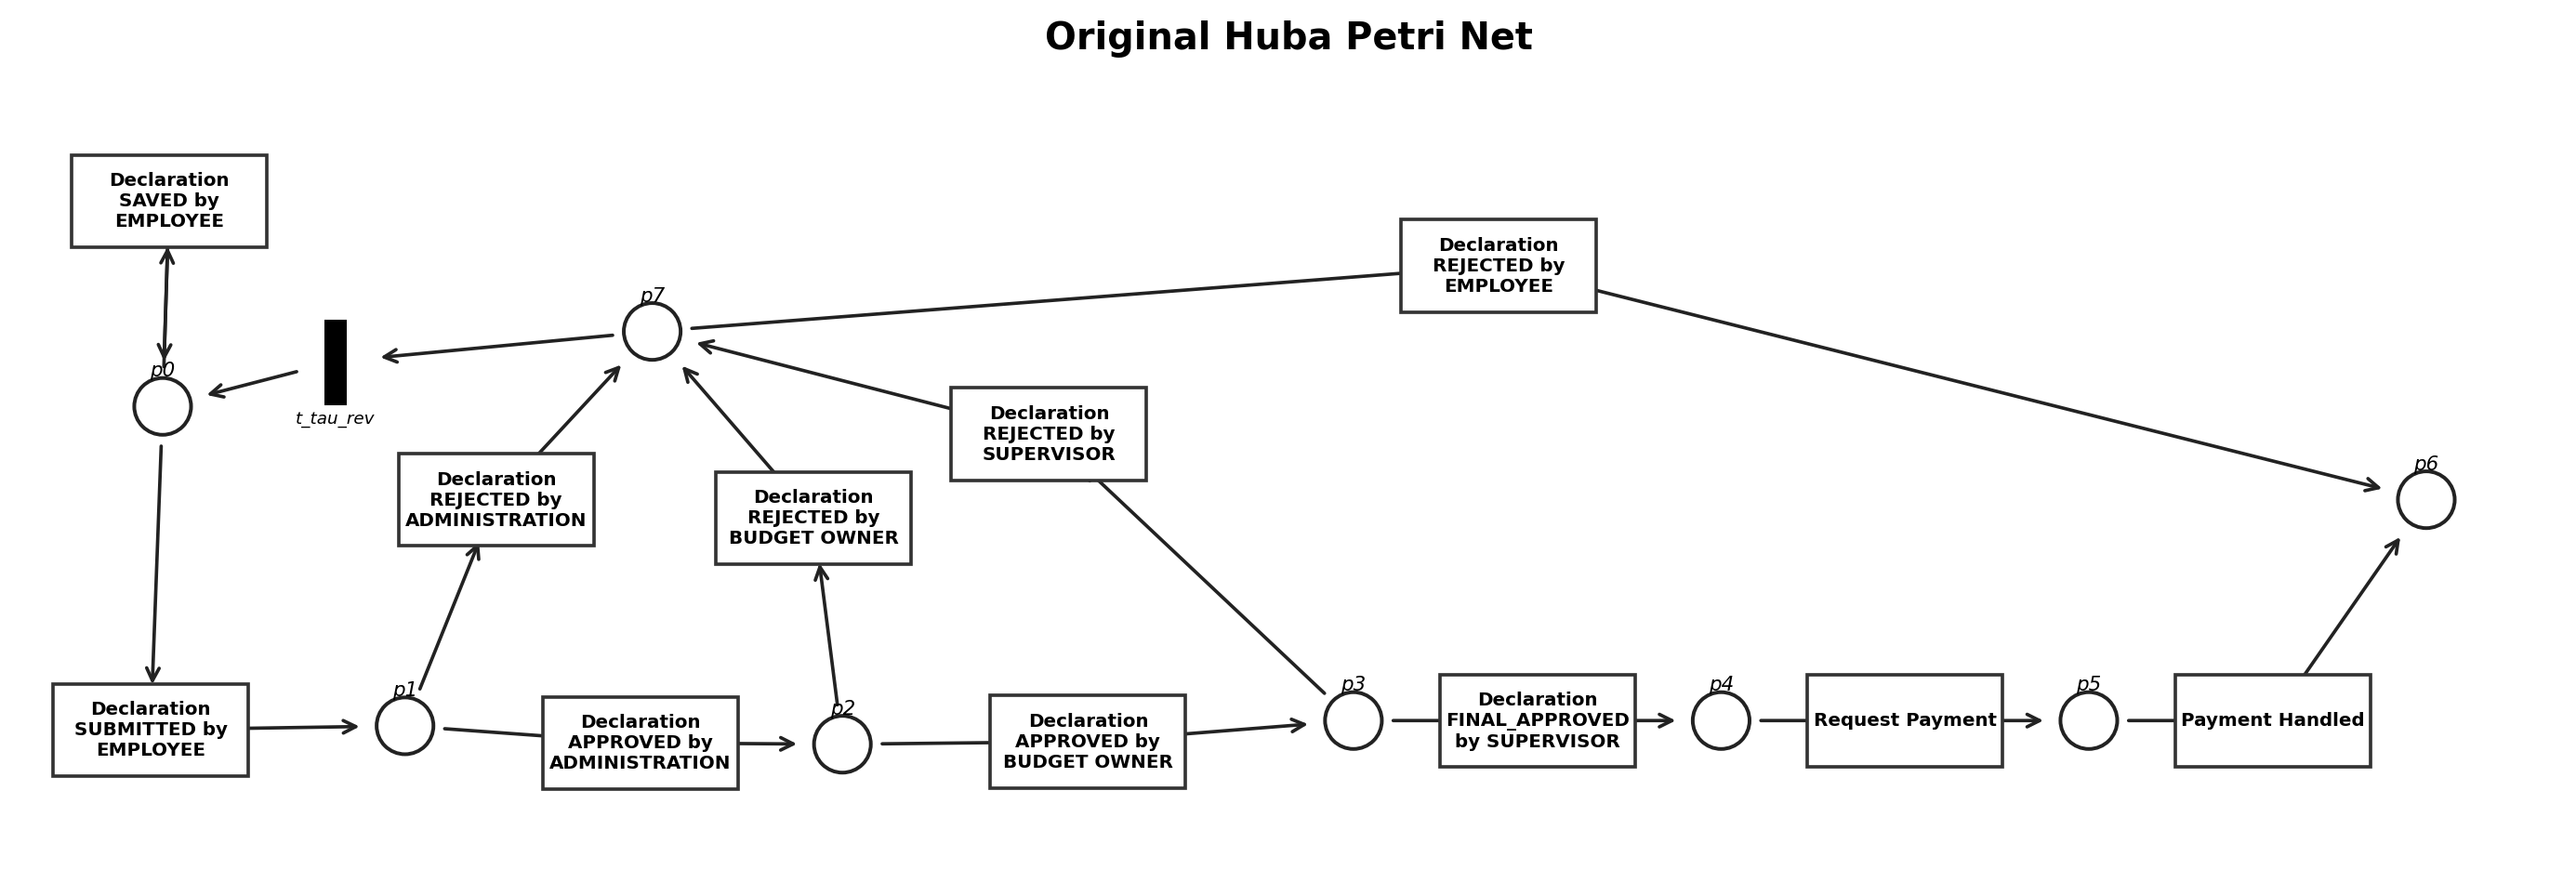


Repaired Huba Petri net


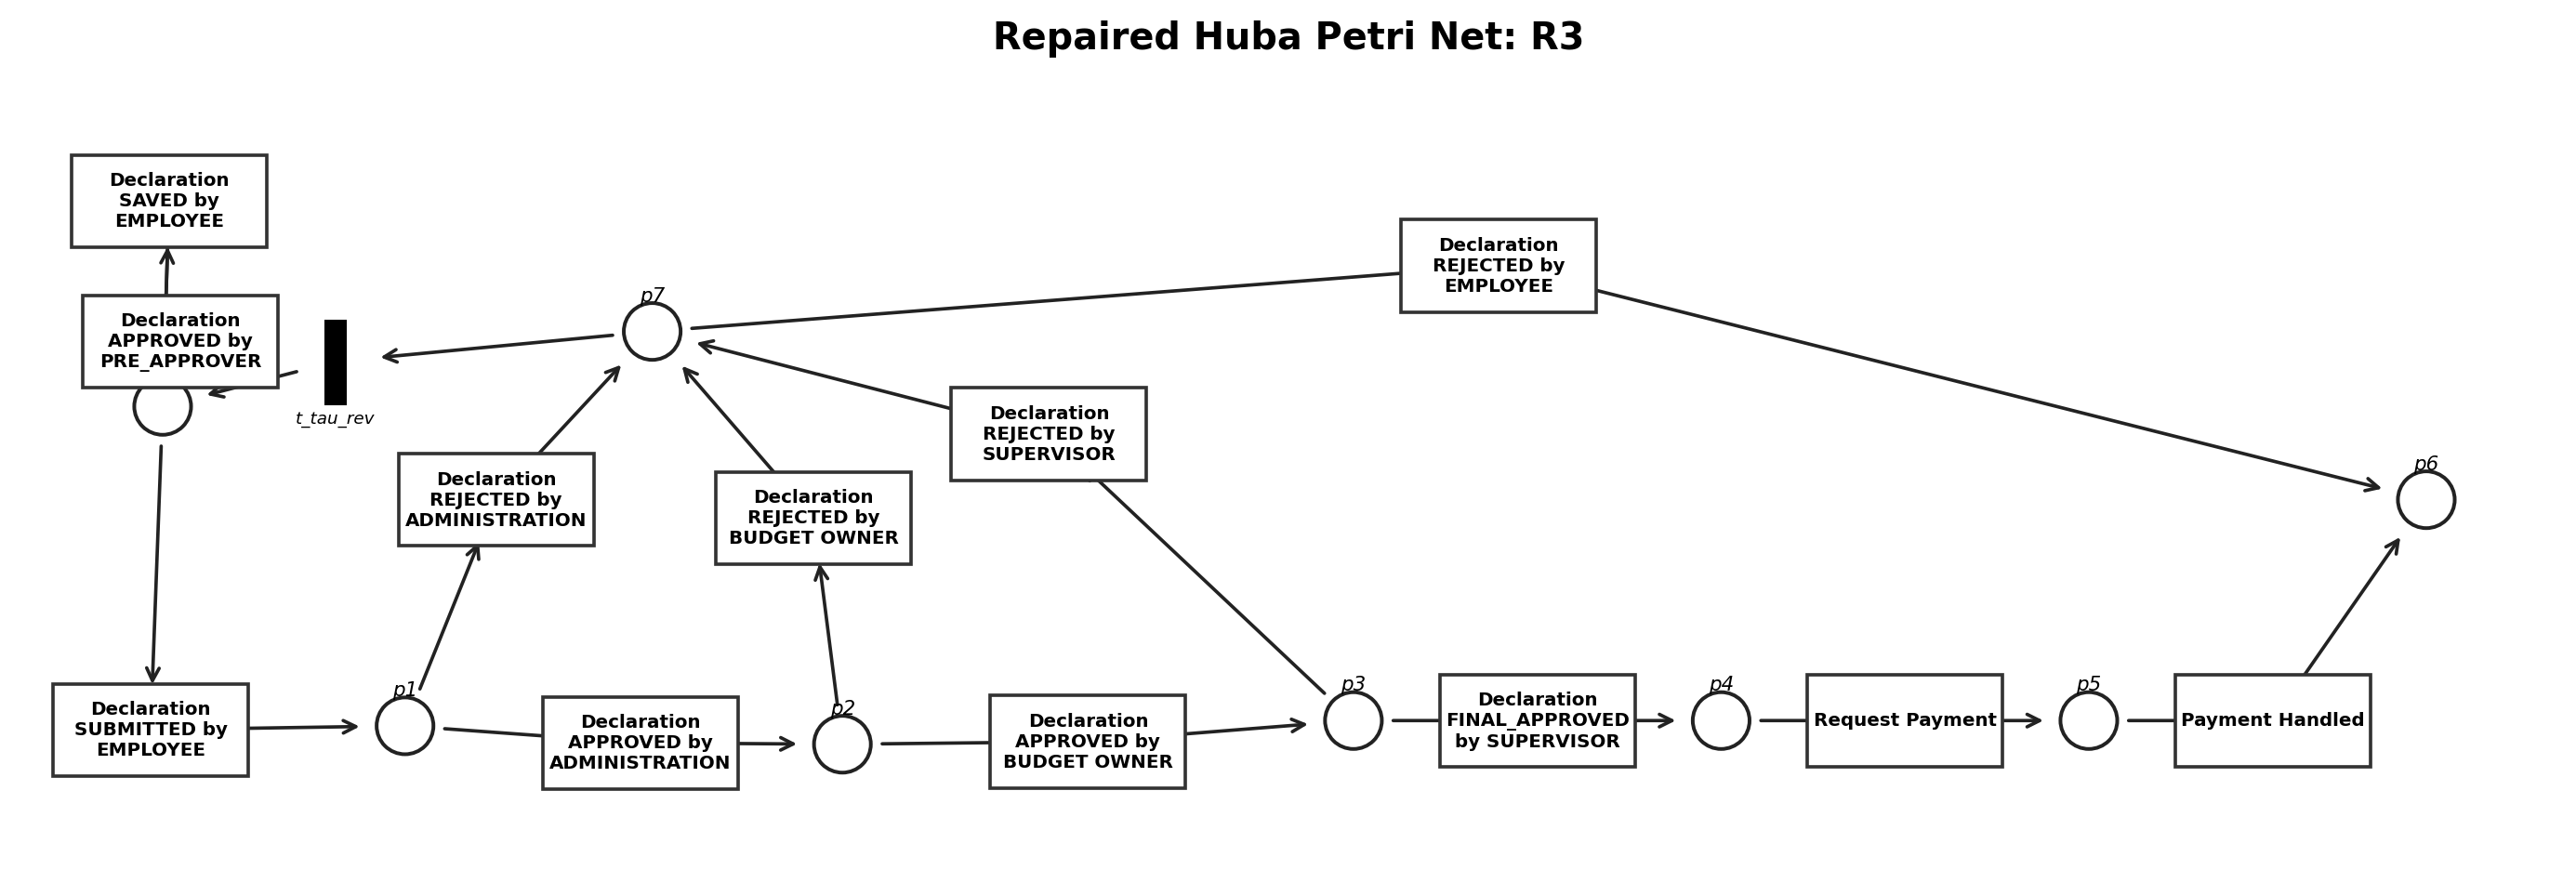

In [25]:
original_pnml_path = REPO_ROOT / PROCESS_MODEL_PATH

print('Original PNML:', original_pnml_path)
print('Repaired PNML:', exported_path)

before_process_style = render_petri_net_process_style_png(
    inputs.petri_net,
    Path('rendered') / 'huba_petri_net_before_process_style.png',
    title='Original Huba Petri Net',
)
after_process_style = render_petri_net_process_style_png(
    selected_variant.petri_net,
    Path('rendered') / f'huba_petri_net_after_{selected_variant.name}_process_style.png',
    title=f'Repaired Huba Petri Net: {selected_variant.name}',
)

print('\nOriginal Huba Petri net')
display(Image(filename=str(before_process_style)))

print('\nRepaired Huba Petri net')
display(Image(filename=str(after_process_style)))


## 14. Re-run GoCCvA on the Repaired Huba Model


In [26]:
rerun_result = rerun_goccva_for_variant(selected_variant, inputs, analysis_log)
if len(rerun_result) == 4:
    after_summary = after_detailed = after_contribution_to_targets = None
    print('GoCCvA rerun failed:', rerun_result[3])
else:
    after_summary, after_detailed, after_contribution_to_targets = rerun_result
    pd.DataFrame(after_summary)


aligning log, completed variants ::   0%|          | 0/4 [00:00<?, ?it/s]

## 15. Render After-Repair Alignments


In [27]:
if after_summary is not None:
    render_from_analysis(
        activity_abbreviations=inputs.activity_abbreviations,
        summary=after_summary,
        detailed=after_detailed,
        contribution_to_targets=after_contribution_to_targets,
        title=f'Huba after repair: {selected_variant.name} ({selected_variant.operation})',
    )


# Huba after repair: R3 (controlled loop)

The following cases illustrate combinations of alignment class and target-fulfilment class. Each table separates the process alignment row from the target-specific interpretation rows.

## 16. Before/After Comparison


In [28]:
if after_summary is not None:
    comparison = compare_summary(summary, after_summary, selected_variant.name)
    comparison
